# 🏠 House Price Prediction - Internship Level Project
Complete ML pipeline with EDA, Feature Engineering, Model Comparison and Hyperparameter Tuning.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score
import joblib


## 1️⃣ Rebuilding Realistic Dataset

In [2]:

np.random.seed(42)
n = 800

area = np.random.randint(500, 3000, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
floors = np.random.randint(1, 3, n)
age = np.random.randint(0, 30, n)
distance = np.random.uniform(1, 20, n)
parking = np.random.randint(0, 2, n)

price = (
    area * 0.05 +
    bedrooms * 12 +
    bathrooms * 8 +
    floors * 15 -
    age * 0.5 -
    distance * 2 +
    parking * 10 +
    np.random.normal(0, 5, n)
)

df = pd.DataFrame({
    "Area_sqft": area,
    "Bedrooms": bedrooms,
    "Bathrooms": bathrooms,
    "Floors": floors,
    "Age": age,
    "Distance_to_City": distance,
    "Parking": parking,
    "Price_Lakhs": price
})

df.head()


,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Distance_to_City,Parking,Price_Lakhs
0,1360,1,2,2,13,6.996920,1,114.678520
1,1794,3,2,2,17,13.251819,1,143.299438
2,1630,3,2,2,20,8.507487,1,144.599805
3,1595,5,3,2,20,14.550931,1,162.900063
4,2138,4,3,2,4,4.785090,1,201.330521


## 2️⃣ Feature Engineering

In [3]:

df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]
df["Price_per_sqft"] = df["Price_Lakhs"] / df["Area_sqft"]
df.head()


,Area_sqft,Bedrooms,Bathrooms,Floors,Age,Distance_to_City,Parking,Price_Lakhs,Total_Rooms,Price_per_sqft
0,1360,1,2,2,13,6.996920,1,114.678520,3,0.084322
1,1794,3,2,2,17,13.251819,1,143.299438,5,0.079877
2,1630,3,2,2,20,8.507487,1,144.599805,5,0.088712
3,1595,5,3,2,20,14.550931,1,162.900063,8,0.102132
4,2138,4,3,2,4,4.785090,1,201.330521,7,0.094168


## 3️⃣ Correlation Analysis

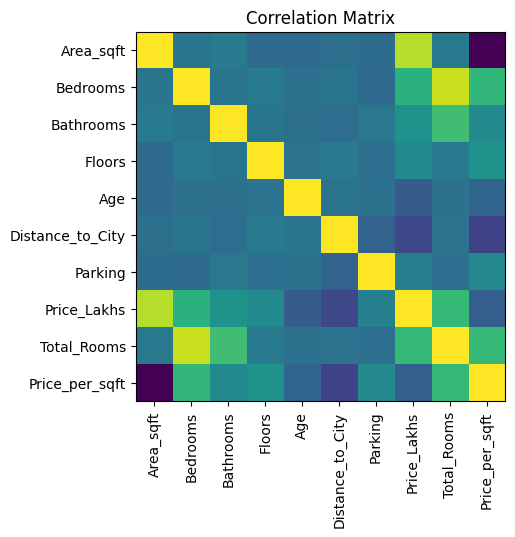

In [4]:

corr = df.corr()

plt.figure()
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()


## 4️⃣ Exploratory Data Analysis

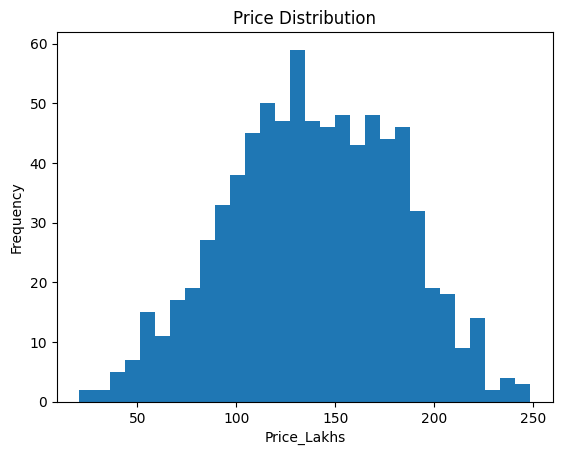

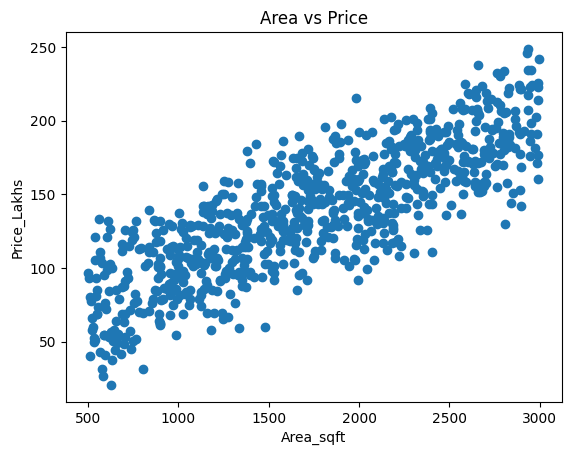

In [5]:

plt.figure()
plt.hist(df["Price_Lakhs"], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price_Lakhs")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.scatter(df["Area_sqft"], df["Price_Lakhs"])
plt.xlabel("Area_sqft")
plt.ylabel("Price_Lakhs")
plt.title("Area vs Price")
plt.show()


## 5️⃣ Model Comparison

In [6]:

X = df.drop("Price_Lakhs", axis=1)
y = df["Price_Lakhs"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    "LinearRegression": LinearRegression(),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(name, "R2 Score:", r2_score(y_test, y_pred))


LinearRegression R2 Score: 0.9889561162492817


## 6️⃣ Hyperparameter Tuning (Random Forest)

In [7]:

param_grid = {
    "n_estimators": [300, 500],
    "max_depth": [None, 20, 30]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

y_pred_final = best_model.predict(X_test)
print("Final R2 Score:", r2_score(y_test, y_pred_final))


Best Parameters: {'max_depth': None, 'n_estimators': 500}
Final R2 Score: 0.9881028029986222


## 7️⃣ Save Final Model

In [8]:

joblib.dump(best_model, "final_house_price_model.pkl")
print("Model Saved Successfully!")


Model Saved Successfully!
